# UE ADSP

# Analogical and Digital Signal Processing
# for sensor data

## TP 2 : Estimation spectrale non paramétrique


### 1. But du TP 
Le but de ce TP consiste à manipuler des signaux à caractère aléatoire et plus spécialement à estimer la DSP (Densité́ Spectrale de Puissance). La fonction d’autocorrélation et sa transformée de Fourier sont de l’information déterministe, mais leur estimation se faisant à partir de réalisation de signaux aléatoires demeure une variable aléatoire. 
Le TP se décompose en plusieurs parties (autrement dit fonctions) à écrire en en Python. On pourra utiliser le notebook fourni qu’il faudra compléter.
Il s’agit, dans un premier temps de modéliser (générer) un signal aléatoire par filtrage d’un bruit blanc.
Si on utilise le bruit blanc gaussien discret $b(n)$ comme excitation d’un filtre linéaire discret, on peut ainsi imposer au signal de sortie $y(n)$ la DSP que l’on souhaite. 
En effet : 

$$\gamma_y (\nu)=|H(\nu)|^2 \gamma_b (\nu)=|H(\nu)|^2 \sigma_b^2=|H(\nu)|^2 N_0$$
avec
$$y(n)=(h*b)(n)$$
- $h(n)$ : réponse impulsionnelle du filtre
- $H(\nu)$ : réponse fréquencielle
- $b(n)$ : bruit blanc gaussien (entrée)
- $y(n)$ : sortie du filtre
  
Il s’agit, ensuite, de vérifier que la forme théorique de la DSP de sortie ($\gamma_y (\nu)$) peut être estimée par l’intermédiaire de deux méthodes d’analyse spectrale : le périodogramme et le corrélogramme. 
Nous utiliserons finalement la génération d’un signal sinusoïdal afin, après l’avoir bruité, de retrouver ses caractéristiques (toujours par analyse spectrale).

- 2.1. Création du signal avec une DSP connue et affichage de la DSP théorique.
  - 2.1.1. Création d'un bruit blanc gausssien
  - 2.1.2. Définir le signal ayant une DSP connue
  - 2.1.3. Création de la DSP théorique
- 2.2. Estimation de la DSP
   - 2.2.1. Periodogramme
   - 2.2.2. Corrélogramme
   - 2.2.3. Méthode de Welch
   - 2.2.4. Méthode de Bartlett
- 2.3. Estimation de la moyenne et de la variance de chaque estimateur 
- 2.4. Test sur un signal contenant 3 sinus.

# 2. TP

## 2.1. Création du signal avec une DSP connue et affichage de la DSP théorique.

- Création du signal
- Création de la DSP théorique

- Importation des librairies python

In [40]:
import dateutil.parser
from dateutil.parser import parse 
import pandas as pd  # This is always assumed but is included here as an introduction.
import numpy as np
import matplotlib.pyplot as plt
from pandas import Series

from pandas.plotting import autocorrelation_plot
from pandas.plotting import register_matplotlib_converters
import scipy
from scipy import signal


# frequence echantillonnage
fs = 1

### 2.1.1 Création de la fonction *Initbruit*

Cette fonction permet la génération d'un bruit blanc gaussien

- input
    - NbPoints : nbre de points
    - sigma : Ecart type du bruit blanc
- output
    - bruit : signal (contenant le bruit)


utilisation de la fonction [*numpy.random.normal*](https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html)

In [41]:
def Initbruit(NbPoints: int, sigma: float) -> np.ndarray:
    mu = 0.0
    np.random.seed(0)
    bruit = np.random.normal(mu, sigma, NbPoints)

    # bruit = à compléter
    return bruit

- Création et affichage du bruit

  - Le nombre de points est égal à 1000
  - L'ecart type du bruit est égal à 1.0  

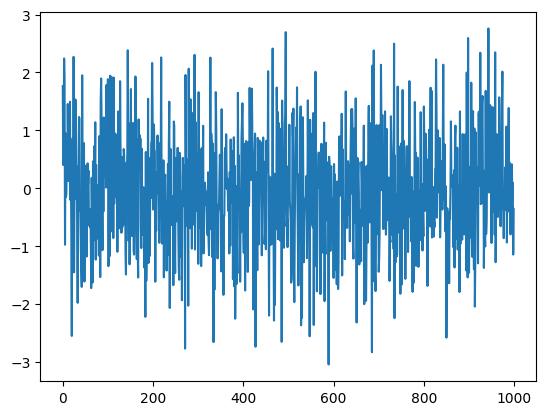

In [42]:
NbPoints = 1_000
ecarttype = 1.0

bruit = Initbruit(NbPoints, ecarttype)

plt.plot(bruit)

### 2.1.2 Création de la fonction *Initsignal*

Filtrage d'un signal par un filtre récursif RII (Réponse Impulsionnelle Infinie).

$$y(n)=-\sum_{j=1}^p{a_jy(n-j)}+\sum_{i=0}^q{b_i bruit(n-i)}$$

filtrage d'un signal par un filtre recursif 
- input
  - bruit : signal d'entrée
  - b : coefficient du numérateur
  - a : coefficient du dénominateur

- output
  - signal : signal filtré

utilisation de la fonction [*signal.lfilter*](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.lfilter.html)

In [43]:
def Initsignal(bruit : np.ndarray, b : list, a : list) -> np.ndarray:
    # signal = à compléter
    signal = scipy.signal.lfilter(b, a, bruit, axis=-1, zi=None)
    
    return signal

- Définir les coefficients du filtre récursif.

- Filtrer le bruit défini en 2.1.1 puis afficher le résultat

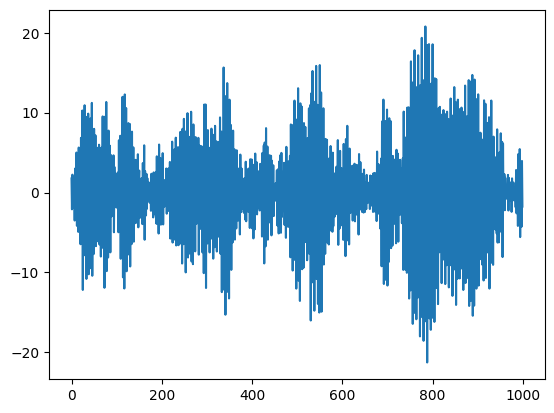

In [44]:
# denominateur
a = [1.0,  1.42, 0.981]
# numerateur
b = [1.]

signalb = Initsignal(bruit, b , a)

plt.plot(signalb)

In [45]:
# Affichage des coefficients des filtres
print("a :",a, " ; b :",b)

a : [1.0, 1.42, 0.981]  ; b : [1.0]


### 2.1.3 Création de la fonction *Gainfiltre* - et de la DSP théorique

Filtrage d'un signal par un filtre IIR.

$$H(z)=\frac{\sum_{i=0}^q{b_i}z^{-i}}{1+\sum_{j=1}^p{a_jz^{-j}}}=\frac{\sum_{i=0}^q{b_i}z^{-i}}{\sum_{j=0}^p{a_jz^{-j}}}$$
avec $b_0=1$

$$H(\nu)=H(z)|_{z=e^{j2\pi \nu /f_e}}$$

gain du filtre entre $-F_e/2$ et $F_e/2$.

- input
  - b, a : coefficients du filtre
  - N : nbre de points

- output
  - w : fréquence
  - h : reponse frequentielle 


 Utilisation de la fonction [*signal.freqz*](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.freqz.html) en sortie on indique les fréquences et la réponse fréquentielle

- Affichage du spectre théorique de $y(n)$ (module en dB).

In [46]:
def Gainfiltre(a : list, b : list, N : int, fs: float) -> np.ndarray | np.ndarray:
    w, h = scipy.signal.freqz(b,a, worN=N, whole=True, fs = fs)
    
    return w, h

Text(0.5, 1.0, 'DSP du signale')

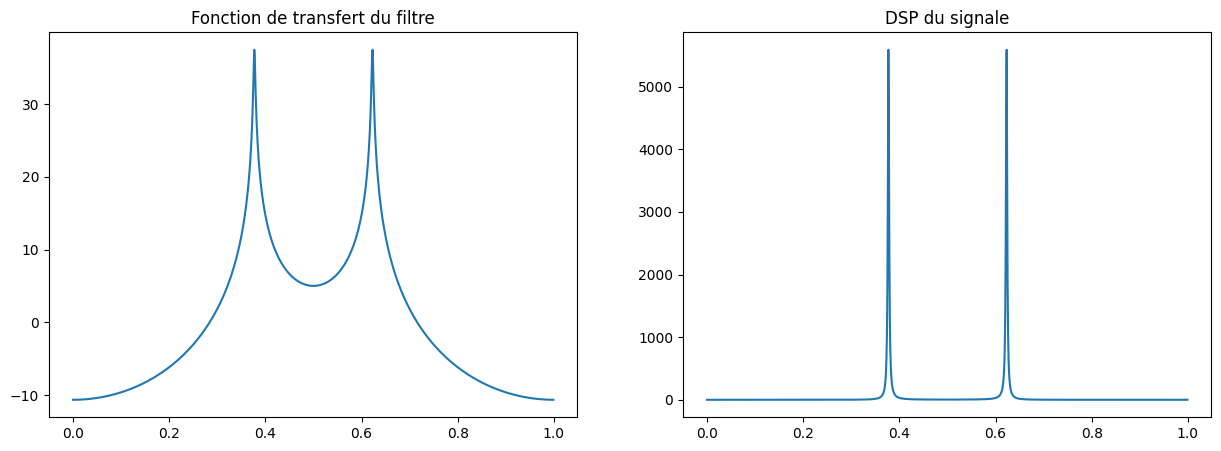

In [47]:
import matplotlib.pyplot as plt
w, h = Gainfiltre(a, b, NbPoints, fs)

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(w, 20*np.log10(np.abs(h)))
plt.title("Fonction de transfert du filtre")
plt.subplot(1,2,2)
plt.plot(w, np.abs(h)**2*ecarttype**2)
plt.title("DSP du signale")

- Décrire et commenter le résultat obtenu (en fonction du filtre choisi).

La répartition de l'énérgie sur deux fréquence principalement

On remarque que le spectre est symétrique. C'est pour cela que souvent seule la partie entre $0$ et $F_e/2$ est affichée.

## 2.2 Estimateur

### 2.2.1 Calcul du periodogramme

- On programme la fonction du periodogram

$$\hat{\gamma}_{perio}(k)=\frac{1}{\Gamma_g(0)}|Y(k)|^2$$

$Y(k)$ est la FFT de $y(n)$

Affichage du résultat (en dB) - comparaison avec le résultat obtenu avec [*scipy.signal.periodogram*](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.periodogram.html) 

[*numpy.fft*](https://numpy.org/doc/2.1/reference/routines.fft.html#module-numpy.fft) indique les différentes fonctions utiles dans le cadre de la fft.

(attention, le spectre doit s'afficher entre $-F_e/2$ et $F_e/2$ et à la normalisation)

- input
  - signalb : signal dont on calcule le periodogramme
  - fs : frequence d'échantillonnage

- output
  - w : frequence 
  - periodogram : le periodogramme (en module)

In [48]:
def Periodogram(signalb, fs = fs):
    
    #periodogram = scipy.signal.periodogram(signalb, fs, return_onesided=False)
    
    Pxx_den = np.abs(np.fft.fftshift(np.fft.fft(signalb)))**2 / (NbPoints)
    f = np.fft.fftshift(np.fft.fftfreq(NbPoints, 1/fs))
    
    return f, Pxx_den

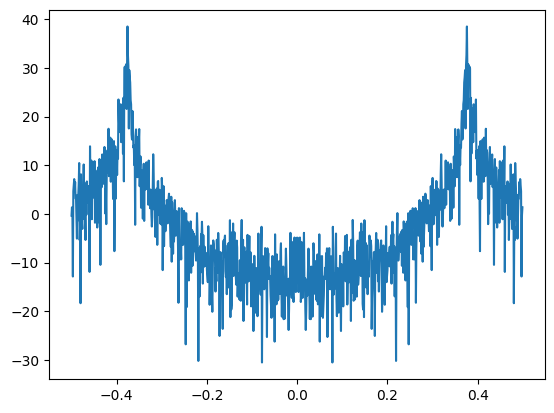

In [49]:
f, Pxx_den = Periodogram(signalb, fs)
plt.plot(f, 10*np.log10(Pxx_den))

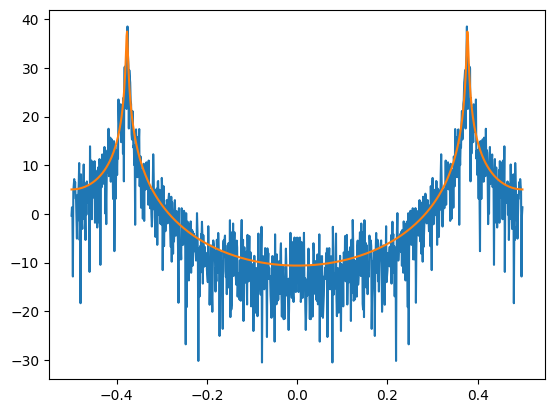

In [50]:
plt.plot(f, 10*np.log10(Pxx_den))
plt.plot(f, 10*np.log10(np.abs(np.fft.fftshift(h))**2*ecarttype**2))

- Calcul du periodogramme en utilisant la définition précédente et affichage du résultat (en dB et en module)

- Comparaison du résultat précédent avec le résultat obtenu par la fonction *scipy.signal.periodogram*


In [51]:
dsp_ = np.fft.fftshift(scipy.signal.periodogram(signalb, fs, return_onesided=False)[1])

In [52]:
print(np.mean((Pxx_den - dsp_)**2))

3.234126541273571e-05


- Décrire, analyser et commenter le résultat obtenu en fonction du gain théorique

L'estmateur n'est pas biaisé mais de grande variance

### 2.2.2 Calcul du correlogramme

$\hat{\gamma}_{corr}(k)$ correspond à la FFT de l'estimation de la fonction d'auto-corrélation.

On estime $\hat{\Gamma}_{corr}(k)$ pour une valeur de $\tau$ comprise entre $-maxlags$ et $maxlags$.

$\hat{\gamma}_{corr}(k)=FFT(\hat{\Gamma}_{corr}(k))$ en effectuant du zero padding pour avoir une estimation de la DSP de même longueur que le signal.

utiliser [*scipy.signal.correlate*](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.correlate.html) et [*scipy.signal.correlation_lags*](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.correlation_lags.html) pour calculer les coefficients de correlation.

- input
  - signalb : signal dont on calcule le correlogramme
  - fs : frequence d'échantillonnage
  - maxlags :
  - norm : 'biaised', 'unbiased'

- output
  - w : frequence 
  - corr : le correlogramme

In [78]:
def Correlogram(signalb, fs = fs, maxlags=600, norm=None):

    corr_ = signal.correlate(signalb, signalb, mode='full')
    coeff = signal.correlation_lags(len(signalb), len(signalb), mode='full')
    
    mask = np.abs(coeff) <= maxlags
    corr_filtered = corr_[mask]
    
    corr = np.zeros(NbPoints)
    
    corr[:maxlags] = corr_filtered[:maxlags]
    corr[-maxlags:] = corr_filtered[maxlags+1:]
    
    corr_fft = np.fft.fft(corr/NbPoints)
    w = np.fft.fftfreq(len(corr_fft), 1/fs)
    
    return np.fft.fftshift(w), np.fft.fftshift(corr_fft)

Calcul et affichage

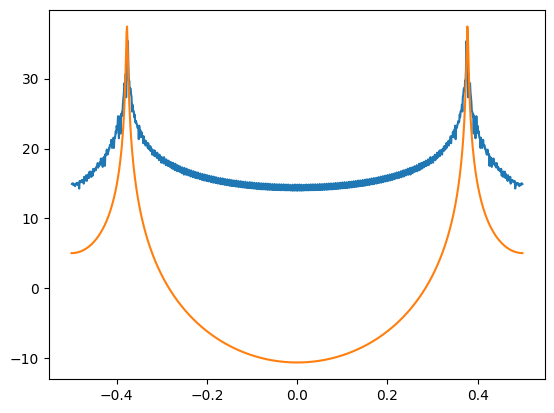

In [ ]:
w, corr = Correlogram(signalb, fs)
plt.plot(w[1:], 10*np.log10(np.abs(corr))[1:])
plt.plot(f, 10*np.log10(np.abs(np.fft.fftshift(h))**2*ecarttype**2))

- Décrire et analyser/expliquer le résultat obtenu (il est conseillé d'afficher les résultats avec  au moins deux valeurs de maxlags différentes, comparer avec le résultat théorique).

### 2.2.3 Periodogram lissé

On applique un filtre passe-bas sur le périodogramme.

On peut utiliser un moyenneur ou bien un filtre gaussien.

Filtre moyenneur de taille $M$ : 
- $h(i) = 1/M$ si $i\in[0,M-1]$
- $h(i)=0$ sinon

[*Filtre gaussien*](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.gaussian_filter1d.html)

Convolution : [np.convolve](https://numpy.org/doc/2.1/reference/generated/numpy.convolve.html)

In [55]:
from scipy import fft

def Periodogramlisse(signalb):
    filtre = np.ones(4) / 4 #scipy.ndimage.gaussian_filter1d([1.0, 2.0, 3.0, 4.0, 5.0], 1)
    periodogramlisse = np.convolve(signalb, filtre)
    
    return periodogramlisse

In [56]:
periodogramlisse = Periodogramlisse(Pxx_den)

Calcul et affichage

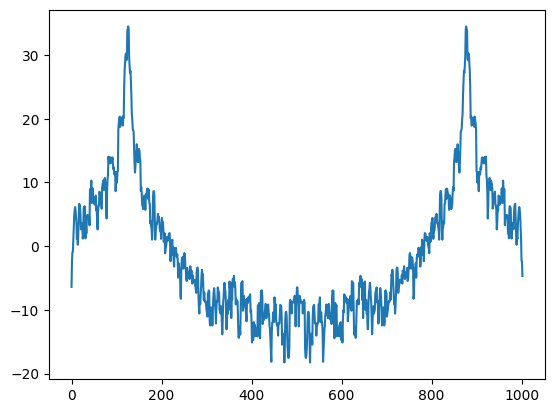

In [57]:
plt.plot(10*np.log10(periodogramlisse))

- décrire, analyser et commenter

### 2.2.4. Méthode Bartlett

La méthode de Bartlett consiste dans les étapes suivantes :

Le segment original est composé de N points. Il est divisé en K (sans chevauchement) sous-segments, chacun de taille M.

Pour chaque segment calculer le périodogramme en calculant la transformée de Fourier discrète. Ensuite. calculez le carré de la magnitude et diviser par M.

Faire la moyenne du résultat des périodogrammes au-dessus pour les K sous-segments.


In [58]:
def bartlett(signal, M = 500): 
    K = int(np.floor(NbPoints/M))
    estim_real = np.zeros((K, NbPoints))
    w = np.fft.fftfreq(NbPoints, 1/fs)

    for k in range(K):
        sig_pre_fft = (signal[k*M:(k+1)*M])
        sig_ = np.zeros(NbPoints)
        sig_[0:M//2] = sig_pre_fft[0:M//2]
        sig_[M//2:M] = sig_pre_fft[M//2:]
        fft_sig = np.fft.fft(sig_).reshape(-1)
        estim_real[k, :] = np.abs(fft_sig)
    return w, np.mean(estim_real, axis = 0)

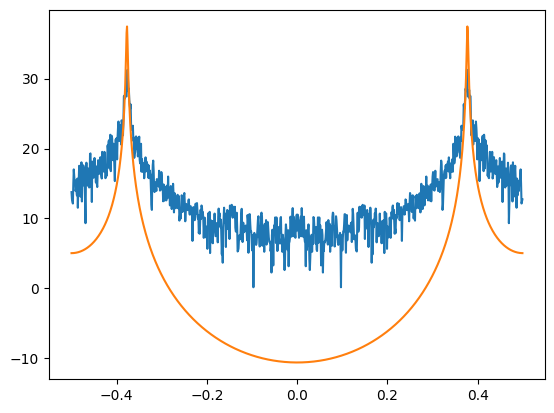

In [ ]:
w, bartlett_dsp = bartlett(signalb)
plt.plot(np.fft.fftshift(w), 10*np.log10(np.fft.fftshift(bartlett_dsp)))
plt.plot(f, 10*np.log10(np.abs(np.fft.fftshift(h))**2*ecarttype**2))

- décrire et commenter

### 2.2.5 Méthode de Welch

Le signal est d'abord décomposé en K fenêtres overlappées de taille M, multipliées, avant transformation, par une fenêtre de pondération (type Hamming, Hanning, Kaiser, ...) ou pas. 

La TF (créée sur Nb points) est ensuite moyennée. 


In [61]:
def welch(signal,  M = 500, O = 100): 
    K = int(np.floor((NbPoints - M)/(M - O)))
    estim_real = np.zeros((K, NbPoints))
    w = np.fft.fftfreq(NbPoints, 1/fs)

    for k in range(K):
        sig_pre_fft = (signal[k*(M-O):k*(M-O) + M])
        sig_ = np.zeros(NbPoints)
        sig_[0:M//2] = sig_pre_fft[0:M//2]
        sig_[M//2:M] = sig_pre_fft[M//2:]
        fft_sig = np.fft.fft(sig_).reshape(-1)

        estim_real[k, :] = np.abs(fft_sig)
    
    return w, np.mean(estim_real, axis = 0)

In [62]:
w, welch_dsp = welch(signalb)

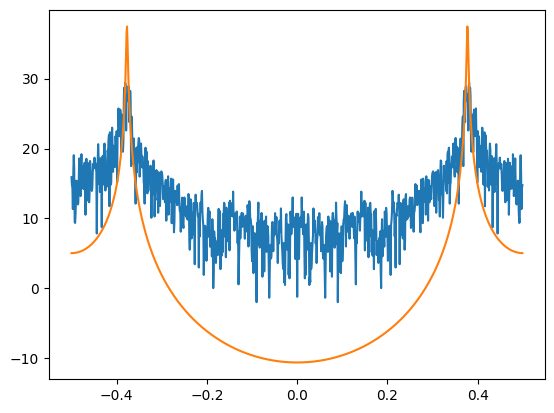

In [63]:
plt.plot(np.fft.fftshift(w), 10*np.log10(np.fft.fftshift(welch_dsp)))
plt.plot(f, 10*np.log10(np.abs(np.fft.fftshift(h))**2*ecarttype**2))

- Décrire, analyser et commenter les résultats obtenus.

## 2.3 Estimation des variances de chaque estimateur

- en boucle
  - générer un signal de bruit
  - le filtrer
  - calculer les DSP (en les stockant dans des tableaux différents de taille (nbreitération, nbpoints))
    
- calculer les moyennes (*numpy.mean*, attention à l'axe axis=0) et les variances (*numpy.var*) pour chaque fréquences pour chaque estimateur
  - pour chaque estimateur
    - afficher l'estimation de la moyenne de l'estimateur 
    - afficher l'estimation de l'écartype 
    - afficher le gain théorique (on pourra en déduire le biais)

In [64]:
def mean_var(estimateur, signal, nbrIteration = 1_000):
    DSPs = np.zeros((nbrIteration, NbPoints))
    for n in range(nbrIteration): 
        w, DSP = estimateur(signal)
        DSPs[n, :] = np.abs(DSP)
    
    mean = DSPs.mean(axis = 0)
    var = (DSPs - mean).mean(axis = 0)
    return mean, var

Text(0.5, 1.0, 'Variance de DSP su signale pour la methode de correlogram')

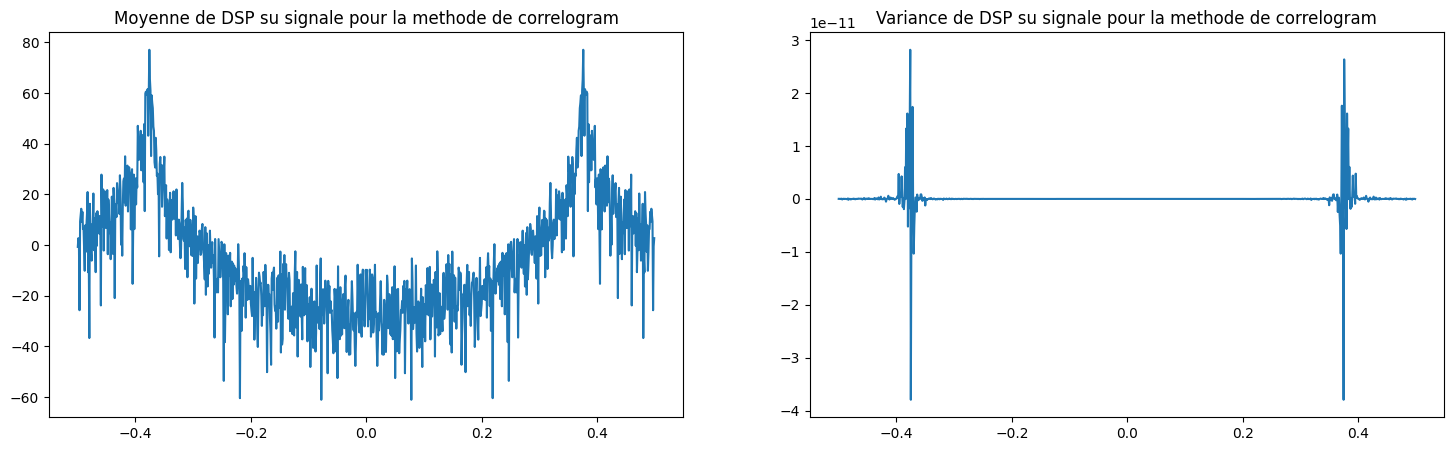

In [65]:
mean, var = mean_var(Periodogram, signalb)
plt.figure(figsize=(18,5))
plt.subplot(1,2,1)
plt.plot(np.fft.fftshift(w), 20*np.log10(mean))
plt.title("Moyenne de DSP su signale pour la methode de correlogram")
plt.subplot(1,2,2)
plt.plot(np.fft.fftshift(w), var)
plt.title("Variance de DSP su signale pour la methode de correlogram")

Text(0.5, 1.0, 'Variance de DSP su signale pour la methode de correlogram')

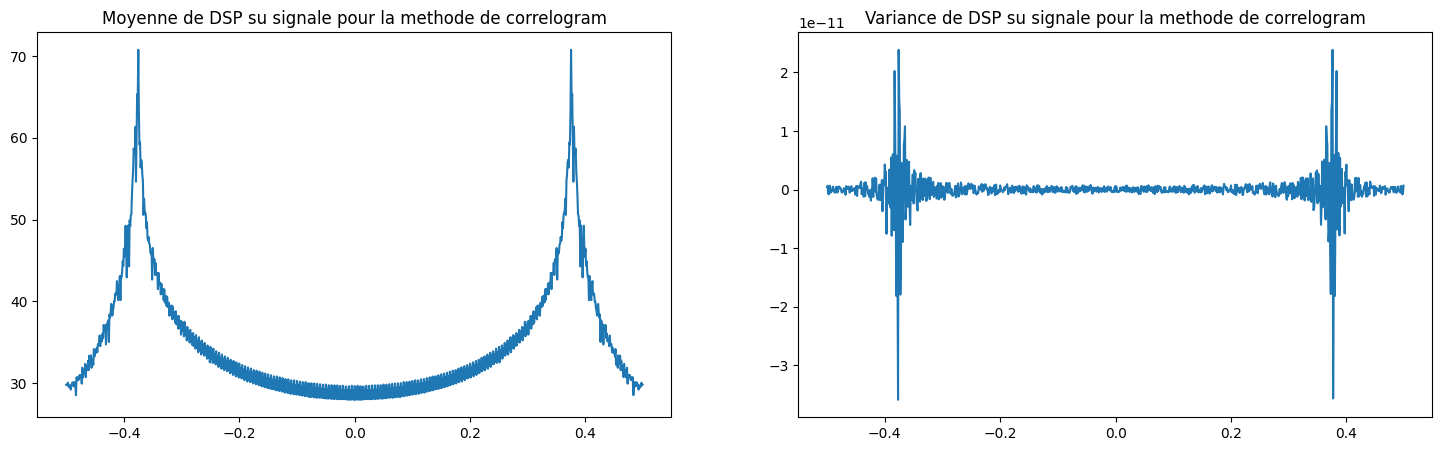

In [66]:
mean, var = mean_var(Correlogram, signalb)
plt.figure(figsize=(18,5))
plt.subplot(1,2,1)
plt.plot(np.fft.fftshift(w), 20*np.log10(mean))
plt.title("Moyenne de DSP su signale pour la methode de correlogram")
plt.subplot(1,2,2)
plt.plot(np.fft.fftshift(w), var)
plt.title("Variance de DSP su signale pour la methode de correlogram")

Text(0.5, 1.0, 'Variance de DSP su signale pour la methode de bartlett')

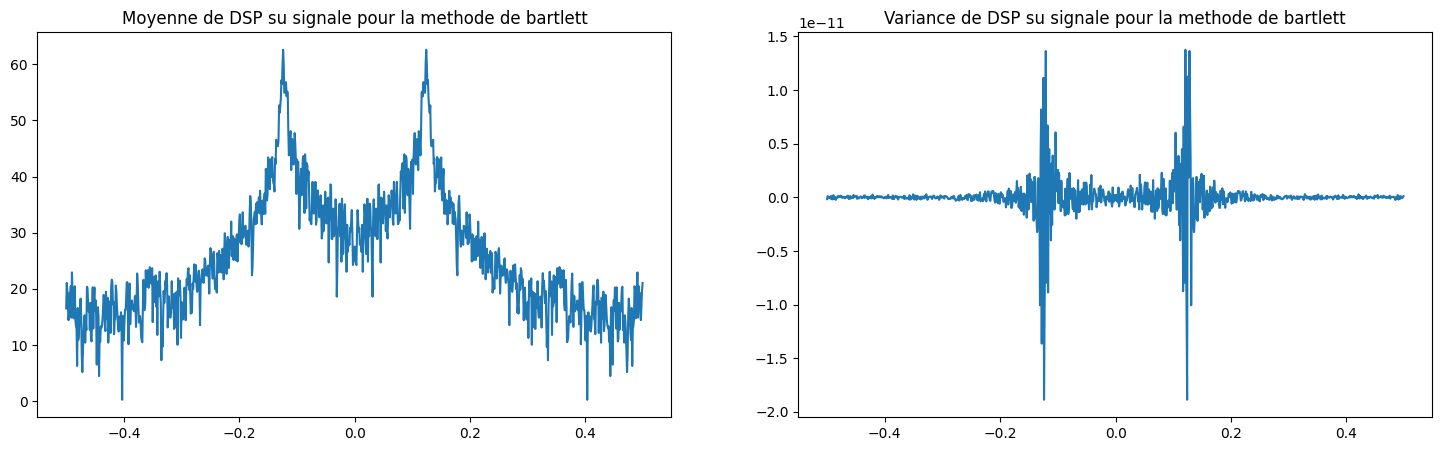

In [67]:
mean, var = mean_var(bartlett, signalb)
plt.figure(figsize=(18,5))
plt.subplot(1,2,1)
plt.plot(np.fft.fftshift(w), 20*np.log10(mean))
plt.title("Moyenne de DSP su signale pour la methode de bartlett")
plt.subplot(1,2,2)
plt.plot(np.fft.fftshift(w), var)
plt.title("Variance de DSP su signale pour la methode de bartlett")

Text(0.5, 1.0, 'Variance de DSP su signale pour la methode de welch')

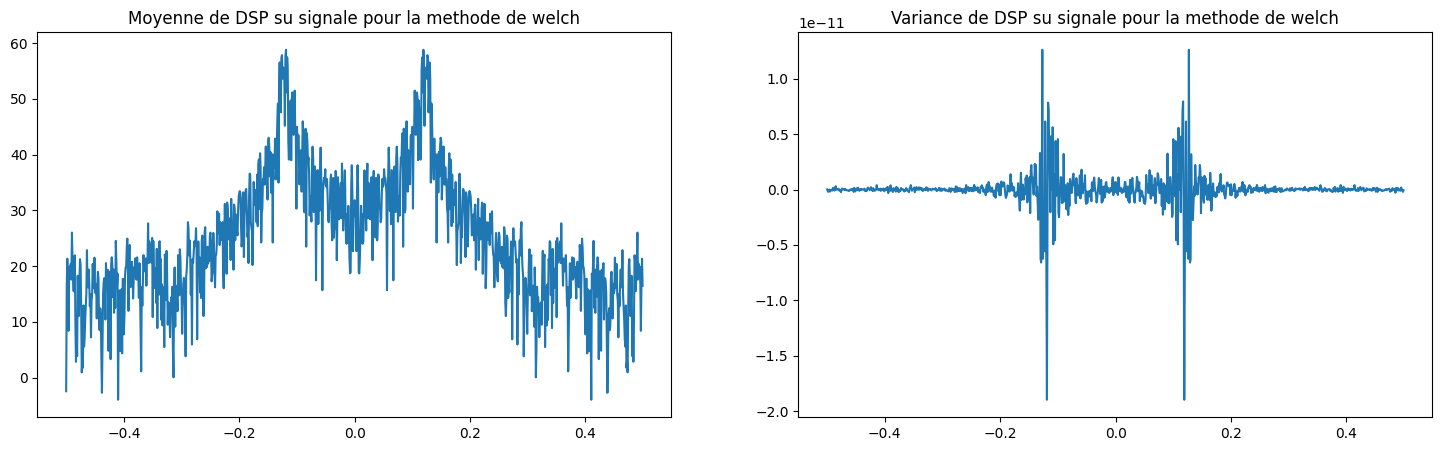

In [68]:
mean, var = mean_var(welch, signalb)
plt.figure(figsize=(18,5))
plt.subplot(1,2,1)
plt.plot(np.fft.fftshift(w), 20*np.log10(mean))
plt.title("Moyenne de DSP su signale pour la methode de welch")
plt.subplot(1,2,2)
plt.plot(np.fft.fftshift(w), var)
plt.title("Variance de DSP su signale pour la methode de welch")

- décrire et analyser les résultats obtenus

- Effectuer une sythèse de vos commentaires sur les différentes méthodes utilisées.

## 2.4 Autre exemple 

Maintenant 

$$y(t)=\cos(2\pi f_1t)+\cos(2\pi f_2t)+\cos(2\pi f_3t)+b(t)$$

avec 
$f_1=0.01$ Hz, $f_2=0.02$ Hz, $f_3=0.06$ Hz et $b(t)$ et un bruit blanc gaussien


Estimer la DSP de $y(t)$ en utilisant les méthodes précédentes.

Commentaires

In [70]:
t = np.linspace(0,1, NbPoints)
f_1, f_2, f_3 = 0.01, 0.02, 0.06
sigma = 0.01
noise = np.random.uniform(0, sigma)
y = np.cos(2*np.pi*f_1*t) + np.cos(2*np.pi*f_2*t) + np.cos(2*np.pi*f_3*t) + noise

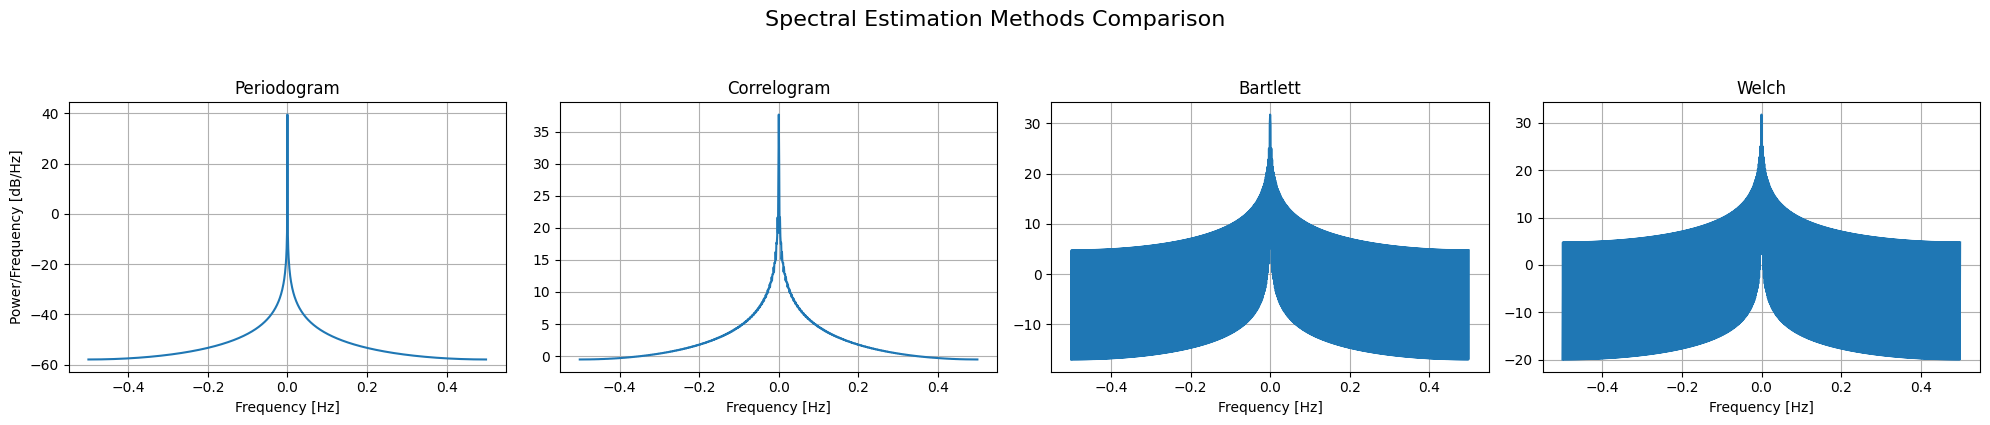

In [106]:
f, Pxx_den = Periodogram(y, fs)
w, corr = Correlogram(y, fs)
w, bartlett_dsp = bartlett(y)
w, welch_dsp = welch(y)

plt.figure(figsize=(20, 4))
plt.suptitle('Spectral Estimation Methods Comparison', fontsize=16, y=1.05)

plt.subplot(1, 4, 1)
plt.plot(f, 10*np.log10(Pxx_den))
plt.title('Periodogram')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power/Frequency [dB/Hz]')
plt.grid(True)

plt.subplot(1, 4, 2)
plt.plot(np.fft.fftshift(w), 10*np.log10(np.abs(corr)))
plt.title('Correlogram')
plt.xlabel('Frequency [Hz]')
plt.grid(True)

plt.subplot(1, 4, 3)
plt.plot(np.fft.fftshift(w), 10*np.log10(np.fft.fftshift(bartlett_dsp)))
plt.title('Bartlett')
plt.xlabel('Frequency [Hz]')
plt.grid(True)

plt.subplot(1, 4, 4)
plt.plot(np.fft.fftshift(w), 10*np.log10(np.fft.fftshift(welch_dsp)))
plt.title('Welch')
plt.xlabel('Frequency [Hz]')
plt.grid(True)

plt.tight_layout()
plt.show()


- décrire et analyser